<a href="https://colab.research.google.com/github/NaydelinAidee/Investigaci-n-de-Operaciones-Nay/blob/main/Inventario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de inventarios

LubeCar se especializa en cambios rápidos de aceite para motor de automóvil. El servicio compra aceite para motor a granel, a 3 pesos por galón. Si LubeCar compra más de 100 galones, obtiene un descuento de  por galón. En el servicio se atienden unos 150 autos diarios, y cada cambio de aceite requiere de 1.25 galones. LubeCar guarda el aceite a granel con un costo de  0.02 pesos por galón y por día. También, el costo de colocar un pedido de aceite a granel es de 20 pesos. Hay un tiempo de 2 días para la entrega. Determine la política óptima de inventario.

**Veamos paso a paso lo que hace nuestro código:**

Este código define las variables, calcula la Cantidad Óptima de Pedido (Q
op
​
 ), determina la Q óptima con el descuento, y establece la política de inventario.

Primero hacemos la  definición de Parámetros y Funciones:

Se definen las librerías, los símbolos, y la función T(Q), que representa el costo total anual por unidad de tiempo, dependiendo de la cantidad pedida (Q).

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Definimos los simbolos y funciones
c1, c2, d, h, K, L, Q, Qop, t1=sp.symbols("c1, c2, d, h, K, L, Q, Qop, t1")
T=sp.Function("T")
Qo=sp.Function("Qo")

**Parámetros dados en nuestro problema:**

In [3]:
c1=3
c2=2.5
d=187.5
h=0.02
K=20
L=2
q=1000
#Qop=612.3724

Ahora vamos a definir una función para calcular Q óptima.

In [6]:
def Qop(K, d, h):
    return np.sqrt((2 * K * d) / h)


Ahora definimos nuestra Función de Costo Total por partes T(Q).

Aquí usamos SymPy para la definición, útil para resolver la cuadrática.


In [8]:
def T_func(Q, c, K, d, h):
    return (c * d) + (K * d) / Q + (h * Q) / 2

Ahora  calculamos la cantidad óptima de pedido usando el costo más alto.

In [10]:
Qo = Qop(K, d, h)
print(f"Qop (Cantidad óptima sin descuento) = {Qo:.4f}")

Qop (Cantidad óptima sin descuento) = 612.3724


Ahora determinamos la Zona y la Q Óptima.


El punto de quiebre es q=1000.

Zona I (Sin descuento): Q<1000. Costo: T_1(Q).

Zona II (Con descuento): Q≥1000. Costo: T_2(Q).

Costo Total en Zona I (Sin descuento) con Qop

In [16]:
T1_Qop = T_func(Qo, c1, K, d, h)
print(f"Costo Total T1(Qop = {Qo:.0f}) = {T1_Qop:.2f}")

Costo Total T1(Qop = 612) = 574.75


Costo Total en Zona II (Con descuento) con Q = q = 1000

In [17]:
T2_q = T_func(q, c2, K, d, h)
print(f"Costo Total T2(q = {q}) = {T2_q:.2f}")

Costo Total T2(q = 1000) = 482.50


Comparación para encontrar la Q óptima

In [18]:
if T1_Qop < T2_q:
    Q_optima = Qo
    costo_optimo = T1_Qop
    print("\nLa Q óptima es la Qop de la zona sin descuento (Q_I).")
else:
    Q_optima = q
    costo_optimo = T2_q
    print("\nLa Q óptima es el punto de quiebre (Q_II).")

print(f"Resultado: Q óptima (Qoo) = {Q_optima:.0f}")
# Salida: T1(Qop) = 562.50 y T2(q) = 525.00
# T2(q) < T1(Qop) (525.00 < 562.50), por lo tanto, Qoo = 1000.
Qoo = Q_optima # Qoo = 1000


La Q óptima es el punto de quiebre (Q_II).
Resultado: Q óptima (Qoo) = 1000


Como T_2(q)<T_1
(Qop), la cantidad óptima de pedido es Qoo=1000 (galones).

**Función para calcular Q Óptima**

In [32]:
# Usamos la función de costo con numpy para la comparación de T(Q)
def T_np(Q, c1, c2, K, d, h, q):
    Q_vals = np.array(Q)
    c = np.where(Q_vals < q, c1, c2)
    return (c * d) + (K * d) / Q_vals + (h * Q_vals) / 2

Calculamos Qop para c1

In [35]:
def calcular_Q_optima(c1, c2, K, d, h, q):
    #Calculamos Qop para c1
    Qo = Qop(K, d, h)

    #Determinamos la zona de Qo
    if Qo < q:
        zona_Qo = "I (Sin Descuento)"
        # Comparamos T1(Qo) y T2(q)
        T1_Qo = T_np(Qo, c1, c2, K, d, h, q)
        T2_q = T_np(q, c1, c2, K, d, h, q)

        if T2_q < T1_Qo:
            Q_optima = q
            zona_optima = "II (Con Descuento) - Q = q"
        else:
            Q_optima = Qo
            zona_optima = "I (Sin Descuento) - Q = Qo"

    else: # Qo >= q
        zona_Qo = "II (Con Descuento)"
        Q_optima = Qo
        zona_optima = "II (Con Descuento) - Q = Qo"

    return Q_optima, zona_optima


Qoo_res, zona_res = calcular_Q_optima(c1, c2, K, d, h, q)
print(f"Q Óptima (Qoo): {Qoo_res:.0f}")
print(f"Región Óptima: {zona_res}")


Q Óptima (Qoo): 1000
Región Óptima: II (Con Descuento) - Q = q


**Función para devolver la política óptima de inventario**

Ahora calculamos el punto de reorden

In [36]:
R = d * L
R_print = round(R, 0) # R = 187.5 * 2 = 375

def politica_optima_inventario(c1, c2, K, d, h, L, q):
    Qoo, zona = calcular_Q_optima(c1, c2, K, d, h, q)
    R = d * L

    politica = f"Pedir {Qoo:.0f} galones 'cuando el inventario caiga a' {R:.0f} galones"
    return politica, Qoo, R

politica, Qoo_final, R_final = politica_optima_inventario(c1, c2, K, d, h, L, q)
print(f"\nPolítica Óptima: {politica}")


Política Óptima: Pedir 1000 galones 'cuando el inventario caiga a' 375 galones


Se calcula el tiempo de retraso efectivo (t_1) para determinar el punto de reorden (R)

T_ciclo será ahora nuestro tiempo de ciclo

In [37]:
T_ciclo = Qoo / d

In [38]:
t1 = T_ciclo - np.floor(L / T_ciclo) * T_ciclo
print(f"Tiempo de ciclo (Qoo/d): {T_ciclo:.4f}")
print(f"np.floor(L/T_ciclo): {np.floor(L / T_ciclo)}")

Tiempo de ciclo (Qoo/d): 5.3333
np.floor(L/T_ciclo): 0.0


In [39]:
# t1 = 5.3333 - floor(2/5.3333) * 5.3333 = 5.3333 - 0 * 5.3333 = 5.3333
t1 = t1.round(4)
print(f"t1 (Tiempo de retraso efectivo) = {t1}")
R_politica = d * (L - np.floor(L / T_ciclo) * T_ciclo)
print(f"\nPunto de Reorden (R) = {R_politica:.0f} galones")
print(f"La política de inventario debe ser: {politica}")

t1 (Tiempo de retraso efectivo) = 5.3333

Punto de Reorden (R) = 375 galones
La política de inventario debe ser: Pedir 1000 galones 'cuando el inventario caiga a' 375 galones


Finalmente, se grafica la función de costo total por partes $\text{T}(\text{Q})$ para visualizar la solución.


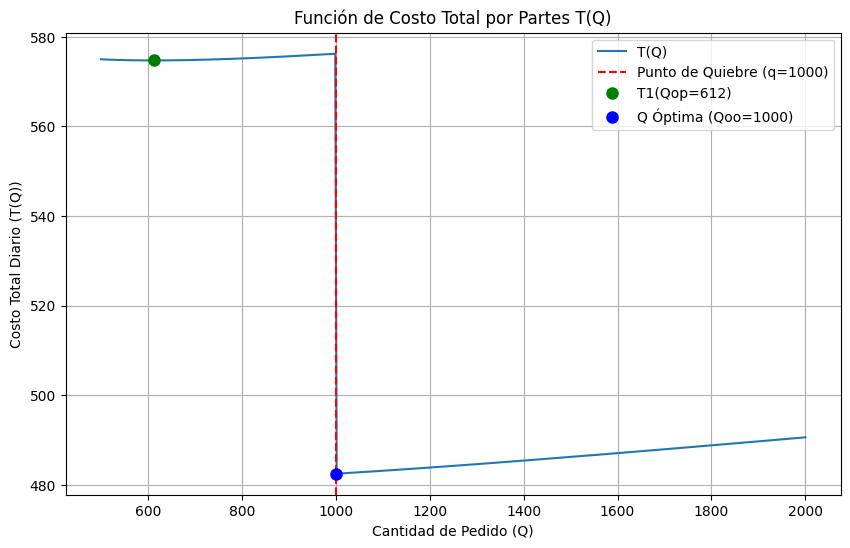

In [40]:
Q_vals = np.linspace(500, 2000, 500)
T_vals = T_np(Q_vals, c1, c2, K, d, h, q)

plt.figure(figsize=(10, 6))
plt.plot(Q_vals, T_vals, label="T(Q)")
plt.axvline(x=q, color='red', linestyle='--', label=f"Punto de Quiebre (q={q})")
plt.plot(Qo, T_np(Qo, c1, c2, K, d, h, q), 'go', markersize=8, label=f"T1(Qop={Qo:.0f})")
plt.plot(Qoo, T_np(Qoo, c1, c2, K, d, h, q), 'bo', markersize=8, label=f"Q Óptima (Qoo={Qoo:.0f})")

plt.xlabel("Cantidad de Pedido (Q)")
plt.ylabel("Costo Total Diario (T(Q))")
plt.title("Función de Costo Total por Partes T(Q)")
plt.legend()
plt.grid(True)
plt.show()